# Stiftung Tierärztliche Hochschule Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Stiftung Tierärztliche Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/015qjqf64' -- 'Stiftung Tierärztliche Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Institute for Animal Hygiene, Animal Welfare, ...",https://openalex.org/W4402751913
1,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Institut für Parasitologie, Zentrum für Infekt...",https://openalex.org/W4404989638
2,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Department of Pharmacology, Toxicology and Pha...",https://openalex.org/W4401075824
3,not assigned,Stiftung Tierärztliche Hochschule Hannover,"University of Veterinary Medicine Hannover, Ha...",https://openalex.org/W4390655908
4,not assigned,Stiftung Tierärztliche Hochschule Hannover,University of Veterinary Medicine Hannover Ha...,https://openalex.org/W4390655908


In [2]:
MAPPING_DICT = {
    'Anatomisches Institut': ['anatomy'],
    #'Arbeitsgruppe Vektor-assoziierte Biodiversität und Infektionen': [],
    'Außenstelle für Epidemiologie': ['epidemiolog(ie|y)'],
    'Fachgebiet Allgemeine Radiologie und Medizinische Physik': ['general radiology', 'department of radiology'],
    #'Gesellschaft für Innovative Veterinärdiagnostik (IVD GmbH)': [],
    #'Hochschulbibliothek': [],
    'Institut für Biochemie': ['bio(chemi(e|stry))'],
    'Institut für Biometrie, Epidemiologie und Informationsverarbeitung': ['biometry'],
    'Institut für Immunologie': ['immunolog(ie|y)'],
    'Institut für Lebensmittelqualität und -sicherheit': ['food quality', 'food safety', 'lebensmittelqualität'],
    'Institut für Lebensmitteltoxikologie und Chemische Analytik': ['food toxicology'],
    'Institut für Mikrobiologie': ['mi(k|c)robiolog(ie|y)'],
    'Institut für Parasitologie': ['parasitolog(ie|y)', 'fish disease'],
    'Institut für Pathologie': ['pharma(k|c)olog(ie|y)', 'patholog(ie|y)'],
    'Institut für Pharmakologie, Toxikologie und Pharmazie': ['neurowissenschaften', 'neuroscience'],
    'Institut für Physiologie und Zellbiologie': ['physiologi(sche|cal) chemi(e|stry)', 'physiolog(ie|y|ical)', 'zellbiologie'],
    'Institut für Reproduktionsbiologie': ['reproductive biology', 'reproduktionsbiologie'],
    'Institut für Terrestrische und Aquatische Wildtierforschung': ['wildtierforschung', 'terrestrial'],
    'Institut für Tierernährung': ['animal nutrition', 'tierernährung'],
    'Institut für Tiergenomik': ['animal genomics'],
    'Institut für Tierhygiene, Tierschutz und Nutztierethologie': ['tierhygiene', 'animal hygiene'],
    'Institut für Tierzucht und Vererbungsforschung': ['animal breeding', 'tierzucht'],
    'Institut für Tierökologie': ['animal ecology', 'ecology and evolution', 'tierökologie'],
    'Institut für Virologie': ['virolog(ie|y)'],
    'Institut für Zoologie': ['zoolog(ie|y)', 'zoologisches institut'],
    'Klinik für Geflügel': ['poultry'],
    'Klinik für Heimtiere, Reptilien, Zier- und Wildvögel': ['reptil(ien|e)'],
    'Klinik für kleine Klauentiere und Forensische Medizin und Ambulatorische Klinik': ['klauentiere', 'forensic', 'clinic for swine'],
    'Klinik für Kleintiere': ['small animal', 'kleintiere', 'neurologie', 'small domestic animals', 'kleintierklinik'],
    'Klinik für Pferde': ['clinic for horses', 'klinik f(ü)?r pferde', 'equine clinic'],
    'Klinik für Rinder': ['clinic for cattle', 'klinik für rinder', 'diseases of cattle', 'cattle clinic'],
    'Lehr- und Forschungsgut Ruthe': ['farm for education( and research ruthe)?', 'forschungsgut ruthe'], #selbst egänzt
    'Reproduktionsmedizinische Einheit der Kliniken': ['biostabilization laboratory', 'reproductive medicine', 'reproduktionsmedizinische'],
    'Research Center for Emerging Infections and Zoonoses (RIZ)': ['zoonos(e|i)s'],
    'Zentrum für E-Learning, Didaktik und Ausbildungsforschung': ['e(-|‐)learning', 'clinical skills lab', 'cent(re|er) for teaching'] #selbst ergänzt
}

In [3]:
with open('./mapping_tables_fak/tiho.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [647]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [648]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [649]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,"Institut für Tierhygiene, Tierschutz und Nutzt...",Stiftung Tierärztliche Hochschule Hannover,"Institute for Animal Hygiene, Animal Welfare, ...",https://openalex.org/W4402751913
1,Institut für Parasitologie,Stiftung Tierärztliche Hochschule Hannover,"Institut für Parasitologie, Zentrum für Infekt...",https://openalex.org/W4404989638
2,Institut für Pathologie,Stiftung Tierärztliche Hochschule Hannover,"Department of Pharmacology, Toxicology and Pha...",https://openalex.org/W4401075824
3,None,Stiftung Tierärztliche Hochschule Hannover,"University of Veterinary Medicine Hannover, Ha...",https://openalex.org/W4390655908
4,None,Stiftung Tierärztliche Hochschule Hannover,University of Veterinary Medicine Hannover Ha...,https://openalex.org/W4390655908
...,...,...,...,...
4813,Institut für Tierernährung,Stiftung Tierärztliche Hochschule Hannover,"Institute for Animal Nutrition, University of ...",https://openalex.org/W3156085509
4814,Institut für Lebensmittelqualität und -sicherheit,Stiftung Tierärztliche Hochschule Hannover,"Institute of Food Quality and Food Safety, Uni...",https://openalex.org/W4417427185
4815,Außenstelle für Epidemiologie,Stiftung Tierärztliche Hochschule Hannover,"Institute of Biometry, Epidemiology and Inform...",https://openalex.org/W4417427185
4816,Klinik für Pferde,Stiftung Tierärztliche Hochschule Hannover,"Biostabilization Laboratory, Lower Saxony Cent...",https://openalex.org/W4417259730


In [650]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['University of Veterinary Medicine Hannover, Hanover, Lower Saxony, Germany',
       'University of Veterinary Medicine Hannover  Hanover Lower Saxony Germany',
       'University of Veterinary Medicine Hannover, Hannover, Germany',
       'University of Veterinary Medicine, Hanover 30559, Germany',
       'University of Veterinary Medicine Hannover Victoria Caballero, Texas A&M University at Galveston',
       'Tierärztliche Hochschule Hannover',
       'University of Veterinary Medicine Hannover Foundation, Hannover, Germany',
       'University of Veterinary Medicine Hannover, Foundation, Hannover, Germany',
       'University of Veterinary Medicine [Hannover] (Bünteweg 9, 30559 Hannover, Allemagne - Germany)',
       'University of Veterinary Medicine Hannover, Hanover, 30559, Lower Saxony, Germany',
       'University of Veterinary Medicine Hanover, Hanover, Germany',
       'University of Veterinary Medicine, Bischofsholer Damm 15, 30173 Hannover, Germany',
       'Univers

In [651]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Anatomisches Institut,69
1,Außenstelle für Epidemiologie,258
2,Fachgebiet Allgemeine Radiologie und Medizinis...,14
3,Institut für Biochemie,162
4,"Institut für Biometrie, Epidemiologie und Info...",5
5,Institut für Immunologie,66
6,Institut für Lebensmittelqualität und -sicherheit,203
7,Institut für Lebensmitteltoxikologie und Chemi...,7
8,Institut für Mikrobiologie,87
9,Institut für Parasitologie,254


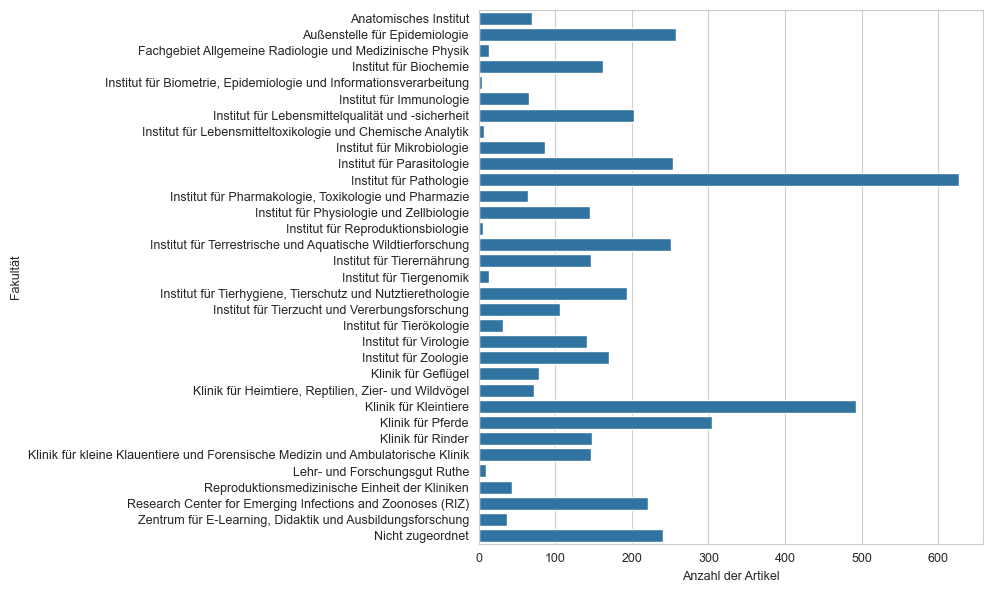

In [652]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [653]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.9499792444997924